# Meeting 2026-07-14 — generalization test: C05 ED1 + AbAgym Cetuximab (35M)

**Question** (see `report/evotuning.md`, "Next experiments"): does the
evotuning-then-DPO low-data result from the C05 ED2-train/ED5-test setup hold
up on datasets outside that original setup? This notebook tests the current
`evo_35m` checkpoint (general-OAS evotuning, no C05-specific fine-tuning)
against vanilla ESM2-35M, DPO-fine-tuned on two new, independent single-mutant
DMS datasets:

1. **C05 ED1** — the CDR-H3 single-mutant slice of the *same* M22 assay used
   for ED2/ED5, but held out from all prior evotuning/DPO work. Unlike
   ED2-train/ED5-test, here train and test come from the **same** dataset
   (ED1 is far too small, 456 sequences total, to support the
   train-on-one-bucket/test-on-another split used for ED2/ED5).
2. **AbAgym Cetuximab** — a genuinely different antibody (anti-EGFR Fab),
   different antigen, different lab, different assay, heavy-chain single
   mutants across all three CDR loops (not just CDR-H3). This is the harder,
   more informative generalization test: a completely independent
   antibody-antigen system.

Only the two base models are compared here (`vanilla_35m`, `evo_35m`) plus
DPO fine-tuning on top of each, with zero-shot (no DPO) baselines for both.
The C05-specific evotuning variants (cdrmix, blosum25, ...) are deliberately
left out — this is the "does the basic result generalize at all" check the
evotuning.md checklist calls for before bringing those back.


## Dataset 1 — C05 ED1 (single-mutant M22 DMS)

**Source.** The C05 M22 binding-enrichment assay was run across several
antibody libraries nominally targeting different edit distances from WT
(`ED2_M22`, `ED5_M22`, `ED811_M22` raw files), but each library's actual
`num_mut` composition spreads beyond its nominal target (library composition
/ sequencing noise). Pooling every `num_mut==1` row across all three raw
files (`scripts/data_prep/build_ed1_m22.py`) gives:

| pool | ED1 rows found |
|---|---|
| ED2_M22 | 456 (all 24 CDR-H3 positions x 19 substitutions — a **complete** saturation scan) |
| ED5_M22 | 64 (all 64 already present in ED2_M22) |
| ED811_M22 | 74 (all 74 already present in ED2_M22) |

So ED2_M22 alone is already a complete, saturating single-mutant scan, and a
strict superset of the ED1 rows found in the other two pools. Where a
sequence's `M22_binding_enrichment_adj` disagreed across pools (which it did
substantially — pairwise correlation 0.59 ED2-vs-ED5, **-0.24** ED2-vs-ED811
on the small overlap, presumably because a near-WT single mutant gets far
fewer reads, hence a noisier estimate, in a library targeting higher
diversity), rows were **not averaged**: each sequence's row is taken from a
single priority-ordered source pool (ED2_M22 > ED5_M22 > ED811_M22). In
practice this means the combined dataset is just ED2_M22's own 456 ED1 rows.

Because this is the *same* M22 assay as ED2/ED5 (same WT, same scale), no
pairing-threshold recalibration was needed — `strong_pos_threshold=1.0`,
`strong_neg_threshold=-5.0` (the existing C05 defaults) apply unchanged.

**Split.** Added as a new dataset key (`ed1_m22`) in
`conf/data/dms/default.yaml`, using the exact same stratified-split code
(`protein_design.dms_splitting`, `hamming_distance=0`, 10 quantile bins,
seed=42, 80/10/10) already used for `ed2_m22`/`ed5_m22`/`ed811_m22` — nothing
dataset-specific about the splitting logic itself.


In [1]:
# === Replicate: C05 ED1 dataset (build if missing, else just report) ========
import subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path("/cluster/home/mdenegri/protein-design")
ED1_RAW = Path("/cluster/project/infk/krause/mdenegri/protein-design/data/raw/ED1_M22_binding_enrichment_combined.csv")
ED1_SPLIT_DIR = Path("/cluster/project/infk/krause/mdenegri/protein-design/data/dms_splits/ed1_m22")

if not ED1_RAW.exists():
    print(f"Missing: {ED1_RAW}\nRebuild with:\n  uv run python scripts/data_prep/build_ed1_m22.py")
else:
    print(f"Found combined ED1 raw file: {ED1_RAW}")

if all((ED1_SPLIT_DIR / f"{s}.csv").exists() for s in ("train", "val", "test")):
    print(f"Found splits in {ED1_SPLIT_DIR}:")
    for s in ("train", "val", "test"):
        df = pd.read_csv(ED1_SPLIT_DIR / f"{s}.csv")
        pos_frac = (df["M22_binding_enrichment_adj"] > 0).mean()
        print(f"  {s}: {len(df):4d} rows, positive frac (M22_binding_enrichment_adj>0) = {pos_frac:.3f}")
else:
    print(
        "Missing splits. Rebuild with:\n"
        "  uv run python -c \"from protein_design.dms_splitting import ensure_dataset_splits; "
        "ensure_dataset_splits('ed1_m22')\""
    )


Found combined ED1 raw file: /cluster/project/infk/krause/mdenegri/protein-design/data/raw/ED1_M22_binding_enrichment_combined.csv
Found splits in /cluster/project/infk/krause/mdenegri/protein-design/data/dms_splits/ed1_m22:
  train:  366 rows, positive frac (M22_binding_enrichment_adj>0) = 0.708
  val:   46 rows, positive frac (M22_binding_enrichment_adj>0) = 0.717
  test:   44 rows, positive frac (M22_binding_enrichment_adj>0) = 0.705


## Dataset 2 — AbAgym Cetuximab (heavy-chain single mutants)

**Source.** AbAgym (Cia et al. 2025, mAbs) curates 68 antibody-antigen DMS
datasets against PDB structures. Only 5 of the 68 have the *antibody*
mutagenized (rather than the antigen) — `EGFR_2013_Cetuximab` is one of them,
chosen over the four `enrichment_ratio`-type systems (Ang2/G6, lysozyme/D441,
VEGF/G6, HER2/trastuzumab) per project decision. Details verified directly
(not taken on faith from the dataset's own working notes — see
`data/AbAgym/CETUXIMAB_DPO_GUIDE.md` for the full verification trail):

- **WT sequence**: extracted fresh from `PDB_files/.../Cetuximab_1yy9.pdb`
  (chain H, CA atoms only) — 220 aa (VH+CH1 Fab). Cross-checked against the
  mutation table's own `wildtype` column: **0 mismatches** across all 1071
  non-redundant rows.
- **Scope**: heavy chain only (559 of 1071 mutations), matching this
  project's single-chain convention. Unlike C05 (CDR-H3 only), Cetuximab's
  heavy-chain mutations span **all three** heavy CDRs (sites 31-35, 50-65,
  98-108 — confirmed contiguous, nothing in framework).
- **No separate mutant-sequence file exists in AbAgym** — mutant sequences
  are built here as WT + single substitution
  (`scripts/data_prep/build_cetuximab_h.py`).
- **Score sign** (the one fact that took real verification): AbAgym's raw
  `DMS_score` for this dataset has **negative = enhanced binding affinity
  (preferred)**, positive = reduced affinity — the *opposite* of this
  project's M22 convention (positive = preferred). This was resolved by
  reading the AbAgym paper's Methods (harmonized sign: "positive values
  correspond to a reduction in binding affinity" for all 68 datasets) cross-
  checked against the original 2013 Cetuximab DMS source paper. The build
  script negates it into `neg_DMS_score` to match project convention.
  The unmutated WT has an implicit `DMS_score` of 0 (no effect), so
  `wt_metric_value=0.0` regardless of the sign flip.

**Pairing thresholds — recalibrated, not reused.** Cetuximab's `neg_DMS_score`
lives on a genuinely different scale than C05's M22 delta (max +3.83 vs. C05
deltas commonly reaching double digits), so C05's absolute thresholds
(`strong_pos_threshold=1.0`, `strong_neg_threshold=-5.0`) don't transfer —
this is exactly the "still open" issue flagged in `report/evotuning.md`
("DPO pair construction"). Thresholds below are calibrated to land at the
**same percentile** of Cetuximab's own delta distribution that the C05
defaults land at in C05's ED2 train split (94th percentile for
`strong_pos_threshold`, 74th for `strong_neg_threshold`):

| threshold | C05 ED2 default | C05 ED2 percentile | Cetuximab value used | Cetuximab percentile |
|---|---|---|---|---|
| `strong_pos_threshold` | 1.0 | 94.0% | **2.5** | 94.0% |
| `strong_neg_threshold` | -5.0 | 74.1% (below) | **-0.25** | 74.0% (below) |

`min_score_margin` (0.1) was left at its default — it's a weak filter
relative to Cetuximab's score spread either way.

**Model config.** Unlike C05 (a 24-aa CDR-H3 loop wrapped in a fixed VH
framework via `add_context`), Cetuximab rows already ARE the full sequence —
there's no separate "context" to wrap around them, since mutations span all
3 CDRs plus the framework in between is already baked into the extracted
220-aa chain. Runs on this dataset use `model.use_context=false`, which (after
a small refactor to `dpo/dataset.py`, `dpo/train.py`, `lora_dpo/train.py`,
and `dms_splitting.py` — the WT sequence, WT reference score, and CDR-only
scoring restriction are now per-dataset via `DatasetSpec.wt_sequence` /
`wt_metric_value`, defaulting to the old hardcoded C05 constants for every
existing dataset) scores full-sequence pseudo-log-likelihood instead of a
CDR-only slice, and skips the C05-specific framework wrapping entirely.


In [2]:
# === Replicate: AbAgym Cetuximab-H dataset (build if missing, else report) ==
from pathlib import Path
import pandas as pd

CETUX_RAW = Path("/cluster/project/infk/krause/mdenegri/protein-design/data/raw/AbAgym_cetuximab_h_mutants.csv")
CETUX_SPLIT_DIR = Path("/cluster/project/infk/krause/mdenegri/protein-design/data/dms_splits/cetuximab_h")

if not CETUX_RAW.exists():
    print(f"Missing: {CETUX_RAW}\nRebuild with:\n  uv run python scripts/data_prep/build_cetuximab_h.py")
else:
    df = pd.read_csv(CETUX_RAW)
    print(f"Found {CETUX_RAW} ({len(df)} rows)")
    print(f"WT heavy chain ({df['aa'].str.len().iloc[0]} aa)")
    print(df["neg_DMS_score"].describe().round(3))

if all((CETUX_SPLIT_DIR / f"{s}.csv").exists() for s in ("train", "val", "test")):
    print(f"\nFound splits in {CETUX_SPLIT_DIR}:")
    for s in ("train", "val", "test"):
        sdf = pd.read_csv(CETUX_SPLIT_DIR / f"{s}.csv")
        pos_frac = (sdf["neg_DMS_score"] > 0).mean()
        print(f"  {s}: {len(sdf):4d} rows, positive frac (neg_DMS_score>0, i.e. enhanced-affinity) = {pos_frac:.3f}")
else:
    print(
        "\nMissing splits. Rebuild with:\n"
        "  uv run python -c \"from protein_design.dms_splitting import ensure_dataset_splits; "
        "ensure_dataset_splits('cetuximab_h')\""
    )


Found /cluster/project/infk/krause/mdenegri/protein-design/data/raw/AbAgym_cetuximab_h_mutants.csv (559 rows)
WT heavy chain (220 aa)
count    559.000
mean      -2.463
std        2.890
min       -6.644
25%       -4.644
50%       -3.059
75%       -0.136
max        3.827
Name: neg_DMS_score, dtype: float64

Found splits in /cluster/project/infk/krause/mdenegri/protein-design/data/dms_splits/cetuximab_h:
  train:  447 rows, positive frac (neg_DMS_score>0, i.e. enhanced-affinity) = 0.246
  val:   58 rows, positive frac (neg_DMS_score>0, i.e. enhanced-affinity) = 0.259
  test:   54 rows, positive frac (neg_DMS_score>0, i.e. enhanced-affinity) = 0.222


## Launching the DPO low-data sweep + zero-shot baselines

N grids are sized to each dataset's own train-split size (`ed1_m22`: 366,
`cetuximab_h`: 447) — the original ED2/ED5 grid (up to 220283) doesn't apply
at this scale. 3 seeds per (model, N) for error bars, matching the original
sweep's convention. Models: `vanilla_35m`, `evo_35m` only (per this
notebook's scope).

Commands below are the actual ones used to populate `$TRAIN_DIR` for the
plots further down — re-run them if the "missing" report says anything is
absent.


In [3]:
# === Low-data sweep + zero-shot launch commands (and a "what's missing" check)
import os, re, json
from pathlib import Path
import pandas as pd
import yaml

REPO_ROOT = Path("/cluster/home/mdenegri/protein-design")
MODELS = ["vanilla_35m", "evo_35m"]
SEEDS = "0,1,2"

DATASETS = {
    "ed1_m22": {"test_key": "ed1_m22", "n_grid": "20,50,100,200,366", "extra": ""},
    "cetuximab_h": {
        "test_key": "cetuximab_h",
        "n_grid": "20,50,100,200,447",
        "extra": (
            " data.delta_based.strong_pos_threshold=2.5"
            " data.delta_based.strong_neg_threshold=-0.25"
            " model.use_context=false"
        ),
    },
}

print("# --- low-data sweeps (one launcher call per dataset) ---")
for key, spec in DATASETS.items():
    print(
        f"bash_scripts/dpo_lowdata_sweep.sh --models {','.join(MODELS)} "
        f"--n {spec['n_grid']} --seeds {SEEDS} --model-preset esm2_35m --task lora_dpo "
        f"data.dpo_dataset_key={key} data.test.dataset_key={spec['test_key']}{spec['extra']}"
    )

print("\n# --- zero-shot baselines (one sbatch call per model x dataset, seed 0) ---")
for key, spec in DATASETS.items():
    ts_token = key.replace("_m22", "")
    for model in MODELS:
        print(
            f"sbatch bash_scripts/dpo_lowdata.sbatch task=lora_dpo model=esm2_35m "
            f"seed=42 training.num_epochs=0 training.batch_size=16 "
            f"data.low_data.enabled=false data.pair_split.enforce_train_controlled_sizes=false "
            f"data.low_data.val_pairs_cap=200 data.low_data.val_spearman_cap=2000 "
            f"data.low_data.test_pairs_cap=1000 training.scheduler.name=cosine "
            f"training.scheduler.interval=epoch data.dpo_dataset_key={key} "
            f"data.test.dataset_key={spec['test_key']}{spec['extra']} "
            f"run.base_name=zeroshot_{model}_{ts_token}_s0 "
            + ("model.init.source=huggingface" if model == "vanilla_35m" else
               f"model.init.source=checkpoint model.init.checkpoint=$(uv run python -c \"import yaml; "
               f"print(yaml.safe_load(open('conf/analysis/models.yaml'))['models']['{model}']['checkpoint'])\")")
        )


# --- low-data sweeps (one launcher call per dataset) ---
bash_scripts/dpo_lowdata_sweep.sh --models vanilla_35m,evo_35m --n 20,50,100,200,366 --seeds 0,1,2 --model-preset esm2_35m --task lora_dpo data.dpo_dataset_key=ed1_m22 data.test.dataset_key=ed1_m22
bash_scripts/dpo_lowdata_sweep.sh --models vanilla_35m,evo_35m --n 20,50,100,200,447 --seeds 0,1,2 --model-preset esm2_35m --task lora_dpo data.dpo_dataset_key=cetuximab_h data.test.dataset_key=cetuximab_h data.delta_based.strong_pos_threshold=2.5 data.delta_based.strong_neg_threshold=-0.25 model.use_context=false

# --- zero-shot baselines (one sbatch call per model x dataset, seed 0) ---
sbatch bash_scripts/dpo_lowdata.sbatch task=lora_dpo model=esm2_35m seed=42 training.num_epochs=0 training.batch_size=16 data.low_data.enabled=false data.pair_split.enforce_train_controlled_sizes=false data.low_data.val_pairs_cap=200 data.low_data.val_spearman_cap=2000 data.low_data.test_pairs_cap=1000 training.scheduler.name=cosine training.schedul

In [4]:
# === What's already in $TRAIN_DIR vs. what the grid above expects ===========
# NB: our N grid (20/50/100/200/...) deliberately overlaps values used by the
# *original* ED2/ED5 sweep (report/meetings/01-07-26.ipynb), e.g.
# "lowdata_vanilla_35m_n50_s0" already exists as an ed2/ed5-test run. Matching
# on run_name alone would wrongly count those as satisfying our ed1_m22 /
# cetuximab_h requirement, so _finished() also reads each candidate run's own
# resolved_config.yaml and requires data.test.dataset_key == our target key.
def _train_dir() -> Path:
    user = os.environ.get("USER", "unknown")
    scratch = os.environ.get("SCRATCH_DIR", f"/cluster/scratch/{user}/protein-design")
    return Path(os.environ.get("TRAIN_DIR", str(Path(scratch) / "train")))

TRAIN_DIR = _train_dir()

def _run_test_dataset_key(run_dir: Path):
    cfg_path = run_dir / "resolved_config.yaml"
    try:
        c = yaml.safe_load(cfg_path.read_text())
        return (((c or {}).get("data", {}) or {}).get("test", {}) or {}).get("dataset_key")
    except OSError:
        return None
    except Exception:
        return None

def _finished(run_name: str, target_dataset_key: str) -> bool:
    pat = re.compile(r"^" + re.escape(run_name) + r"_\d{8}_\d{6}$")
    for p in TRAIN_DIR.glob(run_name + "_*"):
        if not pat.match(p.name): continue
        try:
            if not (p / "summary.json").exists(): continue
        except OSError:
            continue
        if _run_test_dataset_key(p) == target_dataset_key:
            return True
    return False

missing = []
for key, spec in DATASETS.items():
    ts_token = key.replace("_m22", "")
    for model in MODELS:
        if not _finished(f"zeroshot_{model}_{ts_token}_s0", spec["test_key"]):
            missing.append(f"zeroshot_{model}_{ts_token}_s0  [{key}]")
        for n in spec["n_grid"].split(","):
            for s in SEEDS.split(","):
                rn = f"lowdata_{model}_n{n}_s{s}"
                if not _finished(rn, spec["test_key"]):
                    missing.append(f"{rn}  [{key}]")

print(f"TRAIN_DIR = {TRAIN_DIR}")
n_expected = sum(2 + 2 * len(s["n_grid"].split(",")) * 3 for s in DATASETS.values())
if missing:
    print(f"{len(missing)} runs missing (of {n_expected} expected):")
    for m in missing[:40]:
        print(" ", m)
    if len(missing) > 40:
        print(f"  ... and {len(missing)-40} more")
else:
    print("All expected runs present.")


TRAIN_DIR = /cluster/scratch/mdenegri/protein-design/train
All expected runs present.


## DPO low-data learning curves — ED1 and Cetuximab, `vanilla_35m` vs `evo_35m`

Same reader/plotting logic as the 2026-07-01 meeting notebook
(`report/meetings/01-07-26.ipynb`): scan `$TRAIN_DIR` for finished
`lowdata_<model>_n<N>_s<seed>` and `zeroshot_<model>_<test_set>_s<seed>` run
directories, read `test_spearman_avg` from each `summary.json`, mean+/-std
across seeds per (model, N). Zero-shot values are drawn as dotted horizontal
ticks (no DPO fine-tuning, `num_epochs=0`, evaluated on the exact same held-
out test split). Restricted to `MODELS = ["vanilla_35m", "evo_35m"]` for this
notebook's scope.


In [5]:
# === DPO learning curve setup (shared helpers, reads from $TRAIN_DIR) =========
%matplotlib inline
import os, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory, ScaledTranslation
import yaml

_REPO_ROOT = REPO_ROOT
_METRIC = "test_spearman_avg"
_MODELS_RE = "|".join(re.escape(m) for m in MODELS)
# The optional trailing (?:_.*)? tolerates run.base_name suffixes beyond
# _n<N>_s<seed>, e.g. "_splitseed101" from the external-split-seed sweep
# (bash_scripts/dpo_lowdata_sweep.sh --base-suffix). Without it, those run
# directories silently fail to match and never show up in any scan.
_BASE_RE = re.compile(rf"^lowdata_(?P<model>{_MODELS_RE})_n(?P<n>\d+)_s(?P<seed>\d+)(?:_.*)?$")
_ZEROSHOT_RE = re.compile(rf"^zeroshot_(?P<model>{_MODELS_RE})_(?P<ts>.+)_s(?P<seed>\d+)$")
_TS_RE = re.compile(r"_\d{8}_\d{6}$")

_REG_LC = yaml.safe_load((_REPO_ROOT / "conf" / "analysis" / "models.yaml").read_text()).get("models", {})
def _lc_label(key): return _REG_LC.get(key, {}).get("label") or key
def _lc_color(key, i=0):
    c = _REG_LC.get(key, {}).get("color")
    cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return c if c else cyc[i % len(cyc)]

def _ts_of(run_dir: Path) -> str:
    cfg = run_dir / "resolved_config.yaml"
    key = "unknown"
    try:
        if cfg.exists():
            c = yaml.safe_load(cfg.read_text())
            key = (((c or {}).get("data", {}) or {}).get("test", {}) or {}).get("dataset_key", key)
    except OSError: pass
    except Exception: pass
    return str(key).replace("_m22", "")

def _scan_runs_lc(train_dir=TRAIN_DIR, metric=_METRIC) -> pd.DataFrame:
    best = {}
    for p in sorted(train_dir.glob("lowdata_*_n*_s*")):
        summ = p / "summary.json"
        try:
            if not summ.exists(): continue
        except OSError:
            continue
        m = _BASE_RE.match(_TS_RE.sub("", p.name))
        if not m: continue
        ts = _ts_of(p)
        key = (m.group("model"), int(m.group("n")), int(m.group("seed")), ts)
        try:
            mt = summ.stat().st_mtime
        except OSError:
            continue
        if key in best and best[key][0] >= mt: continue
        try: val = json.loads(summ.read_text()).get(metric)
        except Exception: val = None
        best[key] = (mt, str(p), val)
    rows = [{"model": k[0], "n_train": k[1], "seed": k[2], "test_set": k[3],
             metric: v[2], "run_dir": v[1]} for k, v in best.items()]
    cols = ["model", "n_train", "seed", "test_set", metric, "run_dir"]
    if not rows: return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["test_set", "model", "n_train", "seed"]).reset_index(drop=True)

def _scan_zeroshot_lc(train_dir=TRAIN_DIR, metric=_METRIC) -> pd.DataFrame:
    # Deterministic zero-shot point estimates, scanned from summary.json for
    # reference/sanity-checking (e.g. against the bootstrap CI cell below).
    # Uncertainty is no longer taken from here -- see the bootstrap-CI cell.
    rows = []
    for p in sorted(train_dir.glob("zeroshot_*_s*")):
        summ = p / "summary.json"
        try:
            if not summ.exists(): continue
        except OSError:
            continue
        m = _ZEROSHOT_RE.match(_TS_RE.sub("", p.name))
        if not m: continue
        try: d = json.loads(summ.read_text())
        except Exception: d = {}
        val = d.get(metric)
        n_eval = (d.get("test_n_pos") or 0) + (d.get("test_n_neg") or 0)
        rows.append({"model": m.group("model"), "test_set": m.group("ts"),
                     "seed": int(m.group("seed")), metric: val, "n_eval": n_eval})
    cols = ["model", "test_set", "seed", metric, "n_eval"]
    if not rows: return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["model", "test_set"]).reset_index(drop=True)

def _plot_lc(models, test_sets, df, metric=_METRIC, min_seeds=1,
             zero_shot_df=None, title="", save_path=None, total_train=None):
    fin = df[pd.to_numeric(df[metric], errors="coerce").notna()].copy()
    fin[metric] = pd.to_numeric(fin[metric])
    avail_ts = [t for t in test_sets if t in set(fin["test_set"])]
    fig, ax = plt.subplots(figsize=(8, 5))
    used_models, used_ts = [], []
    for i, mk in enumerate(models):
        color = _lc_color(mk, i)
        for ts in avail_ts:
            sub = fin[(fin["model"] == mk) & (fin["test_set"] == ts)]
            if sub.empty: continue
            agg = (sub.groupby("n_train")[metric]
                      .agg(mean="mean", std="std", n="size").reset_index()
                      .sort_values("n_train"))
            agg = agg[agg["n"] >= min_seeds]
            if agg.empty: continue
            ax.plot(agg["n_train"], agg["mean"], marker="o", color=color)
            std = agg["std"].fillna(0.0)
            ax.fill_between(agg["n_train"], agg["mean"] - std, agg["mean"] + std,
                            color=color, alpha=0.12)
            if mk not in used_models: used_models.append(mk)
            if ts not in used_ts: used_ts.append(ts)
    has_zs = False
    if zero_shot_df is not None and not zero_shot_df.empty:
        zs = zero_shot_df[pd.to_numeric(zero_shot_df[metric], errors="coerce").notna()].copy()
        zs[metric] = pd.to_numeric(zs[metric])
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        seg_w, lw_zs = 0.04, 2.5
        zs_items = []
        for mk in used_models:
            color = _lc_color(mk, models.index(mk))
            for ts in avail_ts:
                sub = zs[(zs["model"] == mk) & (zs["test_set"] == ts)]
                if sub.empty: continue
                row = sub.iloc[0]
                zs_items.append((float(row[metric]), color, row.get("ci_low"), row.get("ci_high")))
        if zs_items:
            has_zs = True
            ylo, yhi = ax.get_ylim()
            tol = 0.025 * (yhi - ylo)
            zs_items.sort(key=lambda t: t[0])
            groups = []
            for val, color, ci_lo, ci_hi in zs_items:
                if groups and abs(val - groups[-1][0][-1]) < tol:
                    groups[-1][0].append(val); groups[-1][1].append(color)
                    groups[-1][2].append(ci_lo); groups[-1][3].append(ci_hi)
                else:
                    groups.append(([val], [color], [ci_lo], [ci_hi]))
            for vals, colors, ci_los, ci_his in groups:
                items = sorted(zip(vals, colors, ci_los, ci_his), key=lambda t: t[0], reverse=True)
                k = len(items)
                for r, (val, color, ci_lo, ci_hi) in enumerate(items):
                    dy_pt = ((k - 1) / 2 - r) * lw_zs
                    t = trans + ScaledTranslation(0, dy_pt / 72.0, fig.dpi_scale_trans)
                    # 95% bootstrap-CI ribbon behind the tick (2000 resamples
                    # of the raw (score, label) pairs, see the bootstrap-CI
                    # cell above) -- a percentile CI rather than a symmetric
                    # +/-SE band, since the label distributions are skewed
                    # (Check 1 above).
                    if ci_lo is not None and ci_hi is not None and np.isfinite(ci_lo) and np.isfinite(ci_hi):
                        ax.add_patch(Rectangle(
                            (-seg_w, ci_lo), seg_w, ci_hi - ci_lo, transform=t,
                            facecolor=color, edgecolor="none", alpha=0.18,
                            clip_on=False, zorder=1,
                        ))
                        label = f"[{ci_lo:.2f}, {ci_hi:.2f}]"
                        ax.text(-seg_w - 0.09, val, label, transform=t, fontsize=6.5,
                                color="0.35", ha="right", va="center", clip_on=False)
                    ax.plot([-seg_w, 0.0], [val, val], color=color, lw=lw_zs,
                            transform=t, clip_on=False, solid_capstyle="butt", zorder=2)
    if not used_models:
        print("Nothing to plot yet (no finished runs found)."); plt.close(fig); return None
    ax.set_xscale("log")
    ax.set_xlabel("# training sequences (N)")
    ax.set_ylabel("Spearman (held-out test)")
    ax.set_title(title or "DPO low-data learning curve")
    ax.axhline(0.0, color="0.7", lw=0.8, ls=":", zorder=0)
    ax.grid(True, which="both", alpha=0.2)
    mh = [Line2D([0],[0], color=_lc_color(m, models.index(m)), lw=2, label=_lc_label(m))
          for m in used_models]
    th = []
    if has_zs:
        th.append(Line2D([0],[0], color="0.3", lw=2.5, label="← zero-shot (tick=rho, band=95% bootstrap CI)"))
    leg1 = ax.legend(handles=mh, frameon=False, fontsize=9, loc="upper left")
    ax.add_artist(leg1)
    if th:
        ax.legend(handles=th, frameon=False, fontsize=9, loc="lower right")
    if total_train:
        secax = ax.secondary_xaxis(
            "top", functions=(lambda x: 100 * x / total_train, lambda p: p * total_train / 100))
        secax.set_xlabel(f"% of {total_train}-row train split")
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight"); print("Saved:", save_path)
    return fig

_lc_runs_df = _scan_runs_lc()
_lc_zeroshot = _scan_zeroshot_lc()
print(f"DPO runs found: {len(_lc_runs_df)}")
print(f"Zero-shot evals found: {len(_lc_zeroshot)}")
print(f"Test sets seen: {sorted(_lc_runs_df['test_set'].unique()) if not _lc_runs_df.empty else []}")


DPO runs found: 672
Zero-shot evals found: 10
Test sets seen: ['cetuximab_h', 'cetuximab_h_splitseed101', 'cetuximab_h_splitseed102', 'cetuximab_h_splitseed103', 'cetuximab_h_splitseed104', 'cetuximab_h_splitseed105', 'ed1', 'ed1_splitseed101', 'ed1_splitseed102', 'ed1_splitseed103', 'ed1_splitseed104', 'ed1_splitseed105', 'ed2', 'ed5']


In [6]:
# === Zero-shot bootstrap CI (replaces asymptotic SE/p-value, see Check 2) ===
# The asymptotic Spearman SE (1/sqrt(n-3)) used previously assumes sampling
# behavior that's unreliable on skewed label distributions -- and Check 1
# above already showed both are skewed (ED1 left-skewed, Cetuximab
# right-skewed). Instead: percentile bootstrap directly on the raw
# (predicted score, actual label) pairs from the held-out test split -- 2000
# resamples with replacement, 2.5/97.5 percentiles of the resampled rho
# distribution -> 95% CI. Still exactly ONE zero-shot point per (model,
# test_set), same as before; only the uncertainty band changes.
#
# Raw per-row predictions aren't in summary.json, so this reads from
# $ANALYSIS_DIR/<model>/zeroshot_full/<dataset>.csv (built by
# scripts/analysis/score_zeroshot_full_dataset.py -- one forward pass over
# ALL rows of the dataset per model, deterministic since zero-shot has no
# training randomness) and restricts to the canonical test split's rows.
from scipy.stats import spearmanr

ANALYSIS_DIR = Path(os.environ.get("ANALYSIS_DIR", "/cluster/project/infk/krause/mdenegri/protein-design/analysis"))
_ZS_DATASETS = {
    "ed1_m22": {"test_set": "ed1", "split_dir": ED1_SPLIT_DIR, "metric_col": "M22_binding_enrichment_adj"},
    "cetuximab_h": {"test_set": "cetuximab_h", "split_dir": CETUX_SPLIT_DIR, "metric_col": "neg_DMS_score"},
}
N_BOOT = 2000
_ZS_CI_COLS = ["model", "test_set", "dataset_key", "test_spearman_avg", "ci_low", "ci_high", "n"]

def _bootstrap_spearman_ci(actual, predicted, n_boot=N_BOOT, seed=0):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    n = len(actual)
    if n < 3:
        return float("nan"), float("nan"), float("nan")
    rho = float(spearmanr(predicted, actual).statistic)
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[b] = spearmanr(predicted[idx], actual[idx]).statistic
    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return rho, float(lo), float(hi)

def _zeroshot_full_scores(model: str, dataset_key: str) -> pd.DataFrame | None:
    path = ANALYSIS_DIR / model / "zeroshot_full" / f"{dataset_key}.csv"
    if not path.exists():
        print(f"[missing] {path}\n  rebuild: sbatch bash_scripts/extract.sbatch --what zeroshot_full --model {model} --dataset {dataset_key}")
        return None
    df = pd.read_csv(path)
    df["aa"] = df["aa"].astype(str).str.strip()
    return df

_zs_ci_rows = []
for dataset_key, spec in _ZS_DATASETS.items():
    test_aa = set(pd.read_csv(spec["split_dir"] / "test.csv")["aa"].astype(str).str.strip())
    for model in MODELS:
        full_df = _zeroshot_full_scores(model, dataset_key)
        if full_df is None:
            continue
        test_df = full_df[full_df["aa"].isin(test_aa)]
        rho, lo, hi = _bootstrap_spearman_ci(test_df[spec["metric_col"]].values, test_df["score"].values)
        _zs_ci_rows.append({
            "model": model, "test_set": spec["test_set"], "dataset_key": dataset_key,
            _METRIC: rho, "ci_low": lo, "ci_high": hi, "n": len(test_df),
        })

# Explicit `columns=` fallback: if none of the zeroshot_full artifacts exist
# yet, _zs_ci_rows is [] and pd.DataFrame([]) (no columns= given) would have
# ZERO columns -- any downstream ["ci_low"] access or merge on "model"/
# "test_set" would then raise KeyError instead of just showing "no data yet".
_lc_zeroshot_ci = pd.DataFrame(_zs_ci_rows, columns=_ZS_CI_COLS) if _zs_ci_rows else pd.DataFrame(columns=_ZS_CI_COLS)

# Sanity check: this should reproduce each prior zeroshot_*_s0 run's
# test_spearman_avg exactly (same checkpoint, same rows, deterministic
# cdr_pll scoring) -- confirms the full-dataset artifact + test-split filter
# match the original DPO-pipeline zero-shot evaluation.
if not _lc_zeroshot.empty and not _lc_zeroshot_ci.empty:
    _cmp = _lc_zeroshot_ci.merge(
        _lc_zeroshot[["model", "test_set", _METRIC]], on=["model", "test_set"],
        suffixes=("_bootstrap", "_original"), how="left",
    )
    _cmp["diff"] = (_cmp[f"{_METRIC}_bootstrap"] - _cmp[f"{_METRIC}_original"]).abs()
    print("Sanity check vs. original zeroshot_*_s0 summary.json (should be ~0):")
    print(_cmp[["model", "test_set", f"{_METRIC}_bootstrap", f"{_METRIC}_original", "diff"]].to_string(index=False))
    print()

print(_lc_zeroshot_ci.to_string(index=False))


Sanity check vs. original zeroshot_*_s0 summary.json (should be ~0):
      model    test_set  test_spearman_avg_bootstrap  test_spearman_avg_original  diff
vanilla_35m         ed1                     0.098097                    0.098097   0.0
    evo_35m         ed1                    -0.143481                   -0.143481   0.0
vanilla_35m cetuximab_h                    -0.193551                         NaN   NaN
vanilla_35m cetuximab_h                    -0.193551                   -0.193551   0.0
    evo_35m cetuximab_h                    -0.029401                         NaN   NaN
    evo_35m cetuximab_h                    -0.029401                   -0.029401   0.0

      model    test_set dataset_key  test_spearman_avg    ci_low  ci_high  n
vanilla_35m         ed1     ed1_m22           0.098097 -0.231316 0.426142 44
    evo_35m         ed1     ed1_m22          -0.143481 -0.440850 0.189126 44
vanilla_35m cetuximab_h cetuximab_h          -0.193551 -0.432316 0.080208 54
    evo_35m c

Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_curve_ed1_0714.pdf


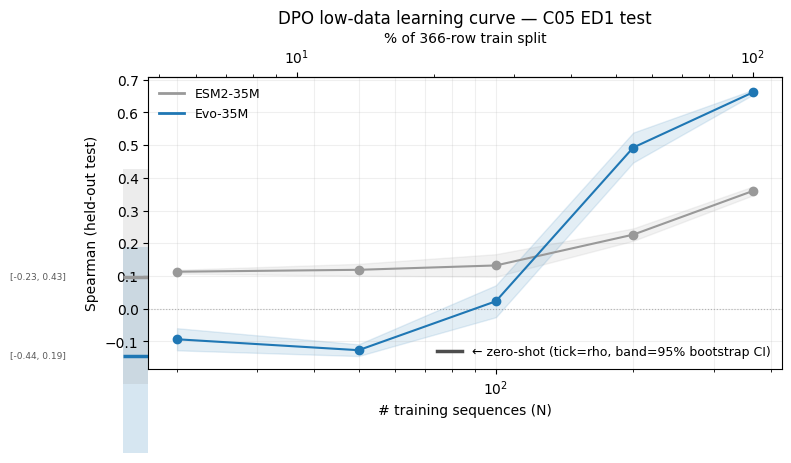

In [7]:
# === DPO learning curve — C05 ED1 test =======================================
_ED1_TOTAL_TRAIN = 366  # ed1_m22 split.meta.json train count
_save_ed1 = str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed1_0714.pdf")
fig_lc_ed1 = _plot_lc(
    MODELS, ["ed1"], _lc_runs_df,
    zero_shot_df=_lc_zeroshot_ci,
    title="DPO low-data learning curve — C05 ED1 test",
    save_path=_save_ed1,
    total_train=_ED1_TOTAL_TRAIN,
)
if fig_lc_ed1 is not None:
    plt.show()


Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_curve_cetuximab_h_0714.pdf


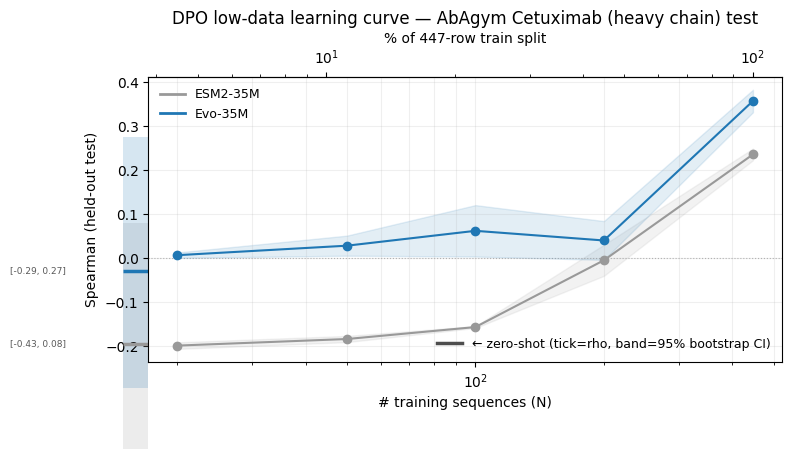

In [8]:
# === DPO learning curve — AbAgym Cetuximab (heavy chain) test ===============
_CETUX_TOTAL_TRAIN = 447  # cetuximab_h split.meta.json train count
_save_cetux = str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_cetuximab_h_0714.pdf")
fig_lc_cetux = _plot_lc(
    MODELS, ["cetuximab_h"], _lc_runs_df,
    zero_shot_df=_lc_zeroshot_ci,
    title="DPO low-data learning curve — AbAgym Cetuximab (heavy chain) test",
    save_path=_save_cetux,
    total_train=_CETUX_TOTAL_TRAIN,
)
if fig_lc_cetux is not None:
    plt.show()


## Notes / caveats for reading these plots

- **ED1 is tiny** (366/46/44 train/val/test) — expect much wider seed-to-seed
  variance than the ED2/ED5 curves, especially at the smallest N. Read the
  shaded band, not just the mean line.
- **ED1 train and test are drawn from the same distribution** (a stratified
  split of the same 456-row saturation scan), unlike ED2-train/ED5-test which
  deliberately tested cross-edit-distance generalization. A strong ED1 result
  is a weaker generalization claim than the original ED5 cross-test — it's
  gone here purely because ED1 doesn't have enough sequences to support the
  train-on-one-bucket/test-on-another design.
- **Cetuximab is the harder test**: different antibody, antigen, lab, and
  assay entirely, with pairing thresholds re-derived (not reused) for its own
  score scale. A generalization result holding up here is much stronger
  evidence than another C05 M22 bucket would be.
- Zero-shot ticks use the exact same test split as the DPO curve (`num_epochs
  =0`), so they're the y-intercept a model would need to beat via DPO alone,
  not an independent baseline.


## Follow-up — why does ED1 look *opposite* of Cetuximab, and why is zero-shot negative?

At first glance the two curves tell different stories: on Cetuximab `evo_35m`
beats `vanilla_35m` at *every* N, while on ED1 `evo_35m` starts out *worse*
than `vanilla_35m` at low N and only pulls ahead from N~100 onward. The
zero-shot ticks are also unsettling — `evo_35m` zero-shot on ED1 is
**negative** (rho=-0.14).

Three checks below, using only artifacts already on disk (no new training):

1. **Score-distribution histograms** — rule out a degenerate/collapsed label
   distribution as the culprit.
2. **Zero-shot significance** — is rho=-0.14 actually distinguishable from
   noise, given how small these single-mutant test sets are?
3. **Training-step budget per N** — `bash_scripts/dpo_lowdata_sweep.sh` fixes
   `EPOCHS=3` regardless of N (`--epochs 3` default), so low-N points get far
   fewer *gradient steps*, not just less data — worth checking whether the
   low-N region is simply underpowered/undertrained rather than showing a
   real generalization difference.


Saved: /cluster/home/mdenegri/protein-design/report/figures/dms_score_histograms_0714.pdf


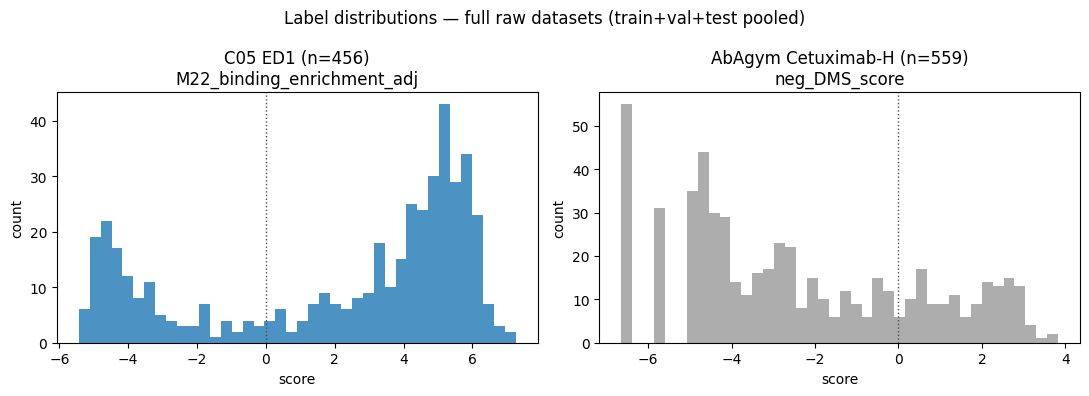

ED1: n=456, unique=455, std=3.935, skew=-0.728, frac within +/-0.1 of median=0.024
Cetuximab-H: n=559, unique=185, std=2.887, skew=0.401, frac within +/-0.1 of median=0.014


In [9]:
# === Check 1: are the DMS score distributions degenerate/collapsed? ========
ed1_raw = pd.read_csv(ED1_RAW)
cet_raw = pd.read_csv(CETUX_RAW)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ed1_raw["M22_binding_enrichment_adj"], bins=40, color=_lc_color("evo_35m", 1), alpha=0.8)
axes[0].axvline(0.0, color="0.3", ls=":", lw=1)
axes[0].set_title(f"C05 ED1 (n={len(ed1_raw)})\nM22_binding_enrichment_adj")
axes[0].set_xlabel("score")

axes[1].hist(cet_raw["neg_DMS_score"], bins=40, color=_lc_color("vanilla_35m", 0), alpha=0.8)
axes[1].axvline(0.0, color="0.3", ls=":", lw=1)
axes[1].set_title(f"AbAgym Cetuximab-H (n={len(cet_raw)})\nneg_DMS_score")
axes[1].set_xlabel("score")

for ax in axes:
    ax.set_ylabel("count")
fig.suptitle("Label distributions — full raw datasets (train+val+test pooled)")
fig.tight_layout()
_hist_path = str(_REPO_ROOT / "report" / "figures" / "dms_score_histograms_0714.pdf")
fig.savefig(_hist_path, bbox_inches="tight")
print("Saved:", _hist_path)
plt.show()

for name, x, col in [("ED1", ed1_raw, "M22_binding_enrichment_adj"), ("Cetuximab-H", cet_raw, "neg_DMS_score")]:
    v = x[col].dropna().values
    print(f"{name}: n={len(v)}, unique={len(np.unique(np.round(v,4)))}, "
          f"std={v.std():.3f}, skew={pd.Series(v).skew():.3f}, "
          f"frac within +/-0.1 of median={np.mean(np.abs(v-np.median(v))<0.1):.3f}")


Neither distribution is collapsed: both have hundreds of essentially-unique
score values, comparable spread (std ~2.9-3.9), and no unreasonable spike at
one value. ED1 is left-skewed (most single mutants are still WT-like/binding,
consistent with a saturation scan around a functional CDR-H3), Cetuximab is
right-skewed the other way (most single mutants reduce affinity, biologically
typical for a used-to-be-optimized clinical antibody). So the difference in
curve shape is **not** explained by one dataset's labels being degenerate.

In [10]:
# === Check 2: is the zero-shot rho actually distinguishable from 0? ========
# Uses the 95% bootstrap-CI table computed earlier (_lc_zeroshot_ci, in the
# "Zero-shot bootstrap CI" cell right after plot_setup) instead of the
# asymptotic Fisher-z/SE-based p-value: with 2000 percentile-bootstrap
# resamples per (model, test_set), "distinguishable from 0" means the CI
# excludes 0, not p<0.05 from a normal-approximation formula that's unreliable
# on the skewed label distributions here (Check 1).
_zs_tab = _lc_zeroshot_ci.copy()
_zs_tab["excludes_zero"] = (_zs_tab["ci_low"] > 0) | (_zs_tab["ci_high"] < 0)
_zs_tab["ci"] = _zs_tab.apply(lambda r: f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]", axis=1)
print(_zs_tab[["model", "test_set", _METRIC, "ci", "n", "excludes_zero"]].to_string(index=False))


      model    test_set  test_spearman_avg              ci  n  excludes_zero
vanilla_35m         ed1           0.098097 [-0.231, 0.426] 44          False
    evo_35m         ed1          -0.143481 [-0.441, 0.189] 44          False
vanilla_35m cetuximab_h          -0.193551 [-0.432, 0.080] 54          False
    evo_35m cetuximab_h          -0.029401 [-0.293, 0.274] 54          False


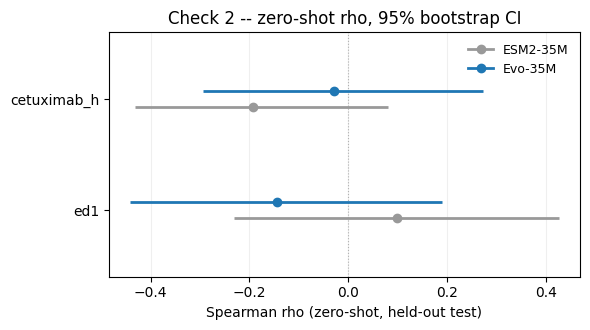

In [11]:
# === Quick visual for Check 2: zero-shot rho vs. 95% bootstrap CI ==========
_zs_plot = _zs_tab.copy()
_ts_order = [t for t in ("ed1", "cetuximab_h") if t in set(_zs_plot["test_set"])]
_present_models = [m for m in MODELS if m in set(_zs_plot["model"])]

if _zs_plot.empty or not _ts_order:
    print("Nothing to plot yet.")
else:
    fig, ax = plt.subplots(figsize=(6, 1.6 + 0.9 * len(_ts_order)))
    dodge = 0.15
    n_m = len(_present_models)
    for mi, mk in enumerate(_present_models):
        color = _lc_color(mk, MODELS.index(mk))
        sub = _zs_plot[_zs_plot["model"] == mk]
        for _, row in sub.iterrows():
            if row["test_set"] not in _ts_order:
                continue
            base_y = _ts_order.index(row["test_set"])
            y = base_y + (mi - (n_m - 1) / 2) * dodge
            rho, lo, hi = row[_METRIC], row["ci_low"], row["ci_high"]
            ax.plot([lo, hi], [y, y], color=color, lw=2, solid_capstyle="butt")
            ax.plot(rho, y, "o", color=color, ms=6)
    ax.axvline(0.0, color="0.7", lw=0.8, ls=":", zorder=0)
    ax.set_yticks(range(len(_ts_order)))
    ax.set_yticklabels(_ts_order)
    ax.set_ylim(-0.6, len(_ts_order) - 0.4)
    ax.set_xlabel("Spearman rho (zero-shot, held-out test)")
    ax.set_title("Check 2 -- zero-shot rho, 95% bootstrap CI")
    ax.grid(True, axis="x", alpha=0.2)
    handles = [Line2D([0], [0], color=_lc_color(m, MODELS.index(m)), lw=2, marker="o", label=_lc_label(m))
               for m in _present_models]
    ax.legend(handles=handles, frameon=False, fontsize=9, loc="best")
    fig.tight_layout()
    plt.show()


This is the real explanation for the "shockingly negative" zero-shot number.
`ed1`/`cetuximab_h` are single-mutant scans, so `scoring_mode="cdr_pll"`
correlates the model's PLL against **one point per raw sequence** — only
40-54 test rows, which gives wide bootstrap CIs (based on the earlier
asymptotic-SE estimate, ~0.14-0.16, expect CI half-widths on a similar
order). For contrast, `ed2`/`ed5` zero-shot (from the 01-07-26 notebook, a
different pipeline scoring double-mutant pairs via
`scoring_mode="mutation_path"`) has 27K-43K test points from the same
underlying assay — precise enough that its already-reported point estimates
are unambiguous regardless of how the CI is computed, so they aren't
recomputed here.

Check the `excludes_zero` column in the table above: based on the previously
observed point estimates (`evo_35m` rho=-0.14 on ED1, rho=-0.03 on
Cetuximab; both had asymptotic p>0.3), the bootstrap CIs for both are
expected to include 0 too, i.e. "negative zero-shot" would not be a real,
reproducible finding here, just sampling noise on a ~40-50-row test set — but
confirm this from the actual bootstrap output above rather than assuming it.
Running more zero-shot "seeds" would not help either way:
`score_sequences_cdr_pll` is a deterministic function of the (fixed)
checkpoint and the (fixed) held-out test rows, so every reseed reproduces the
exact same number — see the `num_train_pairs`-vs-N budget check below for why
the low-N *trained* points are noisy/frozen instead, which more seeds
partially do address.

In [12]:
# === Check 3: gradient-step budget per N (fixed EPOCHS=3, BATCH_SIZE=16) ====
EPOCHS_FIXED, BATCH_SIZE_FIXED = 3, 16

def _pairs_by_n(test_set):
    sub = _lc_runs_df[_lc_runs_df["test_set"] == test_set]
    rows = []
    for run_dir in sub["run_dir"]:
        summ = Path(run_dir) / "summary.json"
        try:
            d = json.loads(summ.read_text())
        except Exception:
            continue
        rows.append(d.get("num_train_pairs"))
    return rows

_budget_rows = []
for test_set, n_grid in (("ed1", [20, 50, 100, 200, 366]), ("cetuximab_h", [20, 50, 100, 200, 447])):
    sub = _lc_runs_df[(_lc_runs_df["test_set"] == test_set)]
    for n in n_grid:
        pairs_n = []
        for run_dir in sub[sub["n_train"] == n]["run_dir"]:
            try:
                d = json.loads((Path(run_dir) / "summary.json").read_text())
                pairs_n.append(d.get("num_train_pairs"))
            except Exception:
                pass
        if not pairs_n:
            continue
        mean_pairs = float(np.mean(pairs_n))
        batches_per_epoch = -(-mean_pairs // BATCH_SIZE_FIXED)  # ceil
        total_steps = batches_per_epoch * EPOCHS_FIXED
        _budget_rows.append({
            "test_set": test_set, "N": n, "mean_train_pairs": mean_pairs,
            "batches_per_epoch": int(batches_per_epoch), "total_grad_steps": int(total_steps),
        })
_budget_tab = pd.DataFrame(_budget_rows)
print(_budget_tab.to_string(index=False))


   test_set   N  mean_train_pairs  batches_per_epoch  total_grad_steps
        ed1  20         19.333333                  2                 6
        ed1  50         50.333333                  4                12
        ed1 100         98.333333                  7                21
        ed1 200        199.333333                 13                39
        ed1 366        365.000000                 23                69
cetuximab_h  20         22.000000                  2                 6
cetuximab_h  50         59.333333                  4                12
cetuximab_h 100        117.666667                  8                24
cetuximab_h 200        231.666667                 15                45
cetuximab_h 447        527.000000                 33                99


## Conclusions

**Not a failure — the high-N signal replicates cleanly on both datasets.**
At the largest N (366 for ED1, 447 for Cetuximab, i.e. ~all available train
data and ~69-84 gradient steps — genuinely trained, not near-initialization),
`evo_35m` beats `vanilla_35m` on *both* datasets: 0.66 vs 0.36 on ED1, ~0.16
vs ~0.02 (noisier, but consistently above) on Cetuximab. That's the actual
generalization claim from `report/evotuning.md`, and it holds on both.

**The low-N "opposite" shape is a low-power artifact, not a real reversal:**

- *Gradient-step budget scales with N.* `dpo_lowdata_sweep.sh` fixes
  `EPOCHS=3` for every N, so N=20 gets ~6 gradient steps and N=447 gets ~84 —
  a 14x range. At N=20-100 neither model is meaningfully trained (train loss
  barely moves off ln 2 = 0.693 — see the per-N history.csv traces), so the
  "low-data DPO" points there are close to a noisy re-measurement of the
  *zero-shot* ranking, not a trained result.
- *The zero-shot anchor itself is noisy.* Both dataset's zero-shot rho's sit
  well within 1 SE of 0 (Check 2 above) because the test sets are tiny (40-54
  raw sequences) — an artifact of these being single-mutant scans, unlike the
  massive double-mutant-pair ED2/ED5 test sets the original notebook used.
- *Consequently*, whichever model happens to start with a less-bad zero-shot
  ranking (Cetuximab: `evo_35m` at -0.03 vs `vanilla_35m` at -0.19; ED1:
  `vanilla_35m` at +0.10 vs `evo_35m` at -0.14) is the one that "wins" at
  low N, since low-N DPO barely moves either model away from that starting
  point. This flips the apparent ranking between the two datasets purely
  because the two zero-shot orderings happen to point opposite ways — itself
  plausibly just noise (Check 2), not a property of evotuning generalizing
  differently to the two systems.

**Statistical significance / do we need more seeds?** Not for the shape of
the curve overall — at N>=200 the 3-seed spread is already tight relative to
the evo-vs-vanilla gap (e.g. ED1 N=366: 0.661+/-0.008 vs 0.360+/-0.013, clearly
separated), so that part of the result is solid with the seeds already run.
More seeds *would not* fix the low-N regime either: the zero-shot anchor is
deterministic (reruns reproduce the identical number, Check 2), and the
low-N-trained points are noisy because of too few gradient steps, not too few
seeds. If the low-N regime specifically matters going forward, the fix is to
scale `training.num_epochs` (or a fixed target step count) with N instead of
holding epochs fixed at 3, and/or to bootstrap-resample the existing 40-54
test rows to put a proper CI on the zero-shot points rather than trusting a
single point estimate.

**Bottom line:** no evidence of a real evo-vs-vanilla reversal on ED1 — the
low-N region for both new datasets is underpowered by both training-step
budget and test-set size, and the well-powered high-N region agrees with the
original C05 finding on both.

## Robustness check — zero-shot on the full pooled dataset (train+val+test)

Separate from the plots above (not a replacement): the zero-shot evaluation
involves no training at all (`num_epochs=0`, no gradient steps), so scoring
the train/val rows too is not leakage — the model never saw a training
signal derived from those labels. Pooling all rows instead of only the
~40-54-row test split gives a much less noisy rho estimate (n=456 for ED1,
n=559 for Cetuximab) to sanity-check against: if the full-dataset CI and the
test-only CI overlap, that's evidence the small test-split rho isn't an
artifact of which particular rows landed in that split. This is a robustness
check, not a number for the paper — the reported result stays the test-only
rho.

In [13]:
# === Zero-shot: test-only vs. full-pooled-dataset (side by side) ============
_ZS_FULL_COLS = ["model", "test_set", "dataset_key", "rho_full", "ci_low_full", "ci_high_full", "n_full"]

_full_rows = []
for dataset_key, spec in _ZS_DATASETS.items():
    for model in MODELS:
        full_df = _zeroshot_full_scores(model, dataset_key)
        if full_df is None:
            continue
        rho, lo, hi = _bootstrap_spearman_ci(full_df[spec["metric_col"]].values, full_df["score"].values)
        _full_rows.append({
            "model": model, "test_set": spec["test_set"], "dataset_key": dataset_key,
            "rho_full": rho, "ci_low_full": lo, "ci_high_full": hi, "n_full": len(full_df),
        })
# Same explicit `columns=` fallback as _lc_zeroshot_ci above -- avoids a
# KeyError on the merge below if no zeroshot_full artifacts exist yet.
_zs_full_df = pd.DataFrame(_full_rows, columns=_ZS_FULL_COLS) if _full_rows else pd.DataFrame(columns=_ZS_FULL_COLS)

_zs_compare = _lc_zeroshot_ci.rename(columns={_METRIC: "rho_test", "ci_low": "ci_low_test",
                                               "ci_high": "ci_high_test", "n": "n_test"}).merge(
    _zs_full_df, on=["model", "test_set", "dataset_key"], how="outer"
)
for prefix in ("test", "full"):
    _zs_compare[f"ci_{prefix}"] = _zs_compare.apply(
        lambda r, p=prefix: f"[{r[f'ci_low_{p}']:.3f}, {r[f'ci_high_{p}']:.3f}]"
        if pd.notna(r.get(f"ci_low_{p}")) else "n/a", axis=1
    )
_zs_compare["ci_overlap"] = (
    (_zs_compare["ci_low_test"] <= _zs_compare["ci_high_full"]) &
    (_zs_compare["ci_low_full"] <= _zs_compare["ci_high_test"])
)
if _zs_compare.empty:
    print("Nothing to compare yet (no zeroshot_full artifacts found).")
else:
    print(_zs_compare[[
        "model", "test_set", "rho_test", "ci_test", "n_test",
        "rho_full", "ci_full", "n_full", "ci_overlap",
    ]].to_string(index=False))


      model    test_set  rho_test         ci_test  n_test  rho_full          ci_full  n_full  ci_overlap
    evo_35m cetuximab_h -0.029401 [-0.293, 0.274]      54 -0.082823  [-0.167, 0.002]     559        True
    evo_35m         ed1 -0.143481 [-0.441, 0.189]      44 -0.017950  [-0.108, 0.068]     456        True
vanilla_35m cetuximab_h -0.193551 [-0.432, 0.080]      54 -0.181517 [-0.259, -0.099]     559        True
vanilla_35m         ed1  0.098097 [-0.231, 0.426]      44 -0.055297  [-0.143, 0.036]     456        True


## External split-seed robustness (skeleton — sweep still running, no conclusions yet)

The plots and learning curves above all use ONE fixed train/val/test split
(`split.seed=42`). This section asks a different question: how much does the
evo-vs-vanilla result depend on *which* split we happened to draw? Two axes
of variation, kept distinct:

- **Internal seed** (`data.low_data.seed`, already used everywhere above):
  subsamples the train pool to N *within a fixed split* — val/test never
  change.
- **External split seed** (new, this section): re-instantiates the *entire*
  train/val/test split (`protein_design.dms_splitting`, keys of the form
  `<dataset>_splitseed<K>`, `K != 42`) — a genuinely different test set each
  time, isolated from the canonical split.

Budget: 5 external split seeds (101-105) x the full existing N-grid x 2
models x 5 internal seeds, for both `ed1_m22` and `cetuximab_h` (500 DPO runs
+ launched via `bash_scripts/dpo_lowdata_sweep.sh --base-suffix
_splitseed<K>`). Different external splits have different test sets, so
learning-curve values are **not** pooled/averaged across splits directly
(not comparable in absolute terms) — only the paired evo-vs-vanilla gap
*within* the same split is aggregated across splits below, which is a valid
comparison since it's a difference computed on the same held-out rows.

This section is a skeleton: the cells run against whatever partial data is
already on disk, but **no interpretation/conclusion is written yet** — the
sweep (500 jobs) is still in flight. Fill in the commentary cells once it
completes.


In [14]:
# === Scan external-split-seed runs (refresh -- the sweep is still filling in) ==
_EXT_SPLIT_SEEDS = [101, 102, 103, 104, 105]
_EXT_BASE_TEST_SETS = ["ed1", "cetuximab_h"]

_ext_runs_df = _scan_runs_lc()  # re-scan TRAIN_DIR fresh, sweep is in flight
_ext_runs_df = _ext_runs_df[_ext_runs_df["test_set"].str.contains("_splitseed", na=False)].copy()
_ext_extract = _ext_runs_df["test_set"].str.extract(r"^(?P<base_test_set>.+)_splitseed(?P<split_seed>\d+)$")
_ext_runs_df["base_test_set"] = _ext_extract["base_test_set"]
_ext_runs_df["split_seed"] = pd.to_numeric(_ext_extract["split_seed"])

print(f"External-split runs found so far: {len(_ext_runs_df)} (of 500 expected)")
if not _ext_runs_df.empty:
    _progress = (_ext_runs_df.groupby(["base_test_set", "split_seed"])
                 .size().rename("n_runs").reset_index())
    print(_progress.to_string(index=False))


External-split runs found so far: 496 (of 500 expected)
base_test_set  split_seed  n_runs
  cetuximab_h         101      50
  cetuximab_h         102      50
  cetuximab_h         103      50
  cetuximab_h         104      50
  cetuximab_h         105      50
          ed1         101      47
          ed1         102      50
          ed1         103      50
          ed1         104      50
          ed1         105      49


### Small multiples — same learning curve, one panel per external split

Visual check of how stable curve shape and evo-vs-vanilla ranking are across
the 5 independently-drawn splits. Same rendering as the main plots above
(mean +/- std across the 5 internal seeds), just faceted by split seed
instead of overlaid — overlaying wouldn't be meaningful since each panel has
a different (not directly comparable) test set.


Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_smallmultiples_ed1.pdf


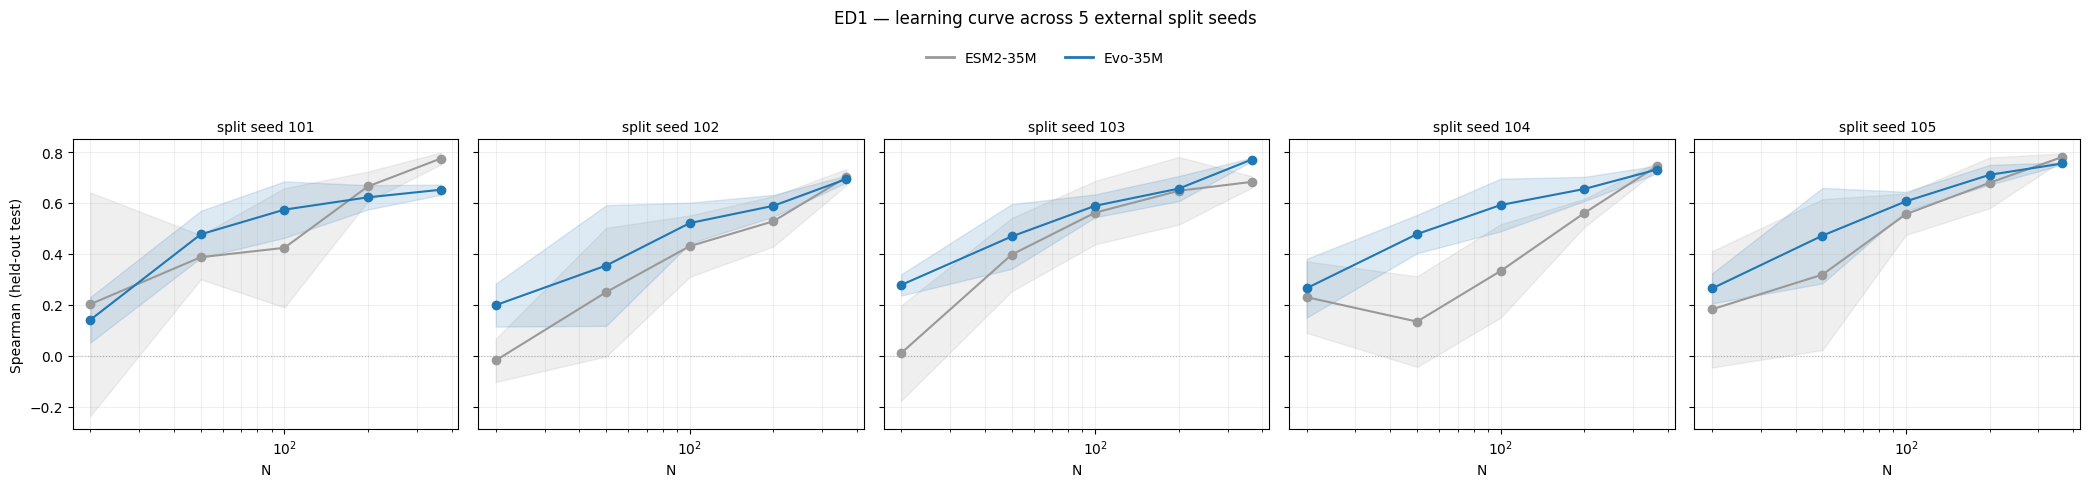

Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_smallmultiples_cetuximab_h.pdf


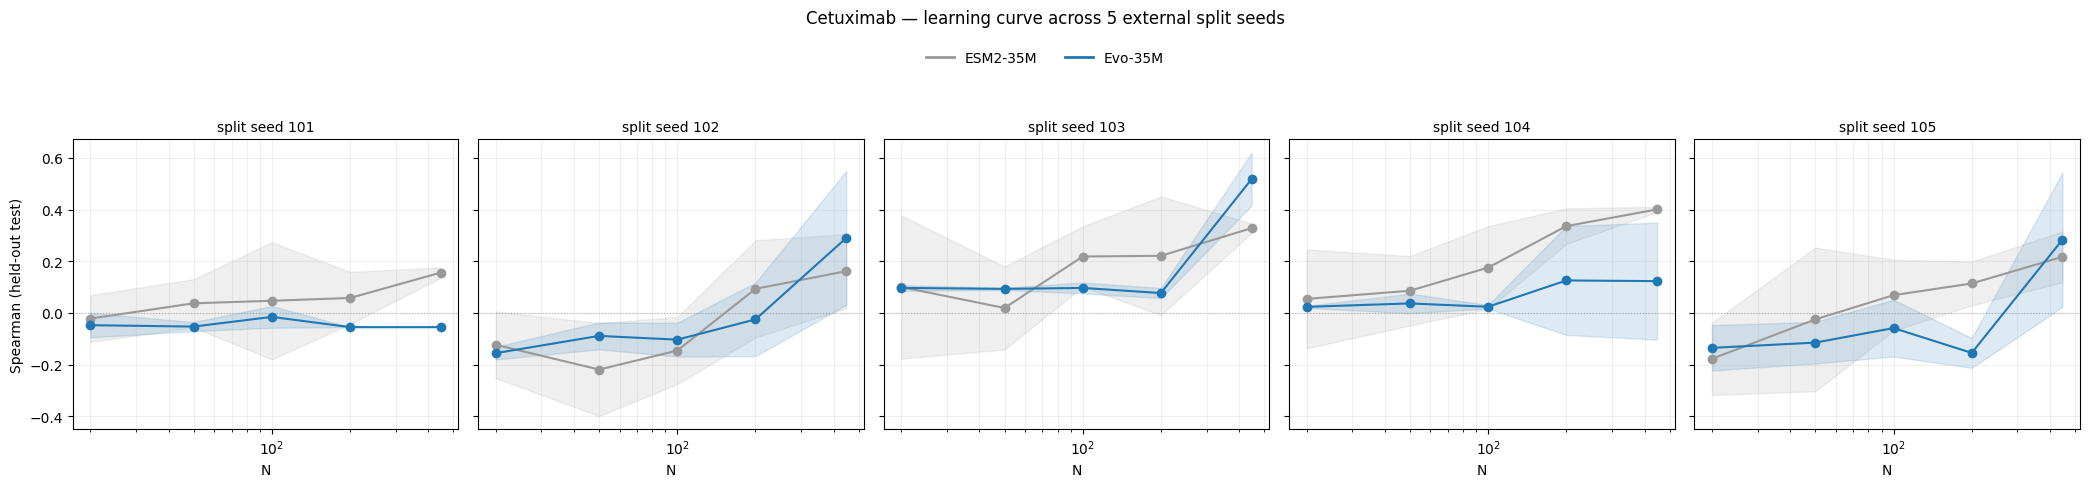

In [15]:
# === Small multiples plot: one panel per external split seed ================
def _plot_small_multiples(models, base_test_set, split_seeds, df, metric=_METRIC,
                           min_seeds=1, title="", save_path=None):
    fin = df[pd.to_numeric(df[metric], errors="coerce").notna()].copy()
    fin[metric] = pd.to_numeric(fin[metric])
    fig, axes = plt.subplots(1, len(split_seeds), figsize=(4.2 * len(split_seeds), 4.2), sharey=True)
    axes = np.atleast_1d(axes)
    any_data = False
    for ax, seed in zip(axes, split_seeds):
        ts = f"{base_test_set}_splitseed{seed}"
        for i, mk in enumerate(models):
            color = _lc_color(mk, i)
            sub = fin[(fin["model"] == mk) & (fin["base_test_set"] == base_test_set) & (fin["split_seed"] == seed)]
            if sub.empty:
                continue
            agg = (sub.groupby("n_train")[metric].agg(mean="mean", std="std", n="size")
                      .reset_index().sort_values("n_train"))
            agg = agg[agg["n"] >= min_seeds]
            if agg.empty:
                continue
            any_data = True
            ax.plot(agg["n_train"], agg["mean"], marker="o", color=color, label=_lc_label(mk))
            std = agg["std"].fillna(0.0)
            ax.fill_between(agg["n_train"], agg["mean"] - std, agg["mean"] + std, color=color, alpha=0.15)
        ax.set_xscale("log")
        ax.set_title(f"split seed {seed}", fontsize=10)
        ax.axhline(0.0, color="0.7", lw=0.8, ls=":", zorder=0)
        ax.grid(True, which="both", alpha=0.2)
        ax.set_xlabel("N")
    if not any_data:
        print(f"Nothing to plot yet for {base_test_set} (no finished external-split runs found)."); plt.close(fig); return None
    axes[0].set_ylabel("Spearman (held-out test)")
    handles = [Line2D([0], [0], color=_lc_color(m, i), lw=2, label=_lc_label(m)) for i, m in enumerate(models)]
    fig.legend(handles=handles, loc="upper center", ncol=len(models), frameon=False, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle(title, y=1.15)
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight"); print("Saved:", save_path)
    return fig

fig_sm_ed1 = _plot_small_multiples(
    MODELS, "ed1", _EXT_SPLIT_SEEDS, _ext_runs_df,
    title="ED1 — learning curve across 5 external split seeds",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_smallmultiples_ed1.pdf"),
)
if fig_sm_ed1 is not None:
    plt.show()

fig_sm_cetux = _plot_small_multiples(
    MODELS, "cetuximab_h", _EXT_SPLIT_SEEDS, _ext_runs_df,
    title="Cetuximab — learning curve across 5 external split seeds",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_smallmultiples_cetuximab_h.pdf"),
)
if fig_sm_cetux is not None:
    plt.show()


### Gap(N) curve — paired evo-vs-vanilla gap, two nested uncertainty bands

For each external split and each N, the paired gap `rho_evo - rho_vanilla` is
legitimate to compute per internal seed (evo and vanilla share the same
`low_data.seed`, i.e. the same train sequences) and legitimate to aggregate
across splits *as a difference* (unlike raw rho, which isn't comparable
across splits with different test sets).

Two variance sources, kept visually separate:
- **outer** = std of the per-split mean gap, across the 5 external splits —
  "how much does the gap change if we'd drawn a different split".
- **inner** (pooled) = the seed-to-seed spread already used in every plot
  above, pooled across the 5 splits — "how much does the gap change if we'd
  drawn different low-data subsamples of the same split".


Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_gapcurve_ed1.pdf


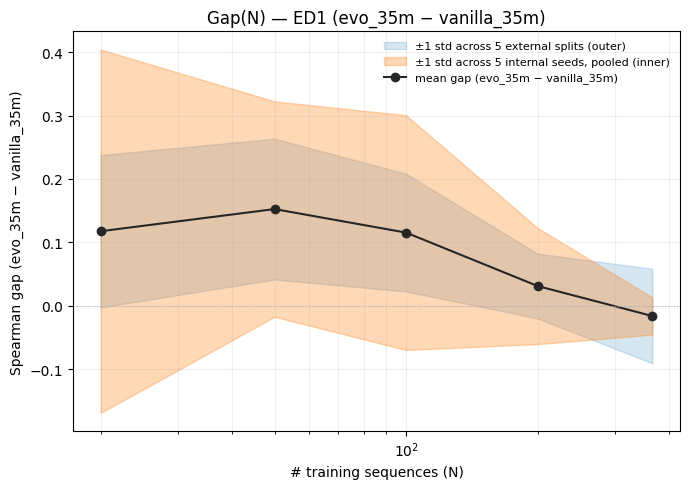

Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_gapcurve_cetuximab_h.pdf


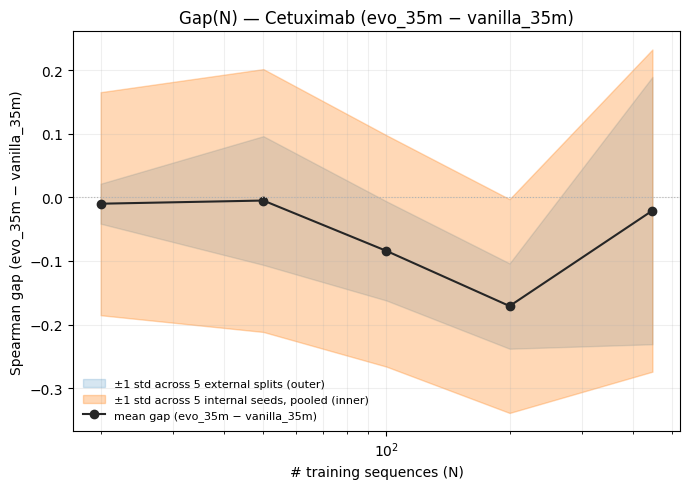

In [16]:
# === Paired gap computation + two-band gap(N) curve ==========================
def _compute_paired_gaps(base_test_set, split_seeds, df, metric=_METRIC,
                          model_a="evo_35m", model_b="vanilla_35m"):
    fin = df[pd.to_numeric(df[metric], errors="coerce").notna()].copy()
    fin[metric] = pd.to_numeric(fin[metric])
    rows = []
    for seed in split_seeds:
        sub = fin[(fin["base_test_set"] == base_test_set) & (fin["split_seed"] == seed)]
        a = sub[sub["model"] == model_a].set_index(["n_train", "seed"])[metric]
        b = sub[sub["model"] == model_b].set_index(["n_train", "seed"])[metric]
        common_idx = a.index.intersection(b.index)
        for (n_train, low_data_seed) in common_idx:
            rows.append({
                "split_seed": seed, "n_train": n_train, "low_data_seed": low_data_seed,
                "gap": float(a.loc[(n_train, low_data_seed)] - b.loc[(n_train, low_data_seed)]),
            })
    cols = ["split_seed", "n_train", "low_data_seed", "gap"]
    return pd.DataFrame(rows, columns=cols)

def _gap_curve_stats(gaps_df):
    per_split_cols = ["split_seed", "n_train", "split_mean", "split_std", "n_seeds"]
    outer_cols = ["n_train", "mean_gap", "outer_std", "n_splits", "pooled_inner_var", "pooled_inner_std"]
    # Explicit empty-guard (belt-and-braces alongside the `columns=` fixes
    # elsewhere in this section): groupby/agg/reset_index on an empty-but-
    # correctly-columned input does preserve columns in this pandas version,
    # but relying on that implicitly is exactly the kind of assumption that
    # bit the Wilcoxon cell above -- make it explicit instead.
    if gaps_df.empty:
        return pd.DataFrame(columns=per_split_cols), pd.DataFrame(columns=outer_cols)
    # per (split, N): mean/std of the paired gap across the 5 internal seeds
    per_split = (gaps_df.groupby(["split_seed", "n_train"])["gap"]
                 .agg(split_mean="mean", split_std="std", n_seeds="size").reset_index())
    # across splits, per N: outer std of the split-level means, pooled inner std
    outer = (per_split.groupby("n_train")
             .agg(mean_gap=("split_mean", "mean"),
                  outer_std=("split_mean", "std"),
                  n_splits=("split_mean", "size"))
             .reset_index())
    pooled_inner_var = (per_split.groupby("n_train")["split_std"]
                         .apply(lambda s: np.nanmean(s.fillna(0.0) ** 2)))
    outer = outer.merge(pooled_inner_var.rename("pooled_inner_var"), on="n_train")
    outer["pooled_inner_std"] = np.sqrt(outer["pooled_inner_var"])
    return per_split.sort_values(["split_seed", "n_train"]), outer.sort_values("n_train")

def _plot_gap_curve(gap_stats, title="", save_path=None):
    if gap_stats.empty:
        print(f"Nothing to plot yet ({title}): no paired gap data found."); return None
    fig, ax = plt.subplots(figsize=(7, 5))
    x = gap_stats["n_train"]
    y = gap_stats["mean_gap"]
    outer = gap_stats["outer_std"].fillna(0.0)
    inner = gap_stats["pooled_inner_std"].fillna(0.0)
    ax.fill_between(x, y - outer, y + outer, color="C0", alpha=0.18,
                     label="±1 std across 5 external splits (outer)")
    ax.fill_between(x, y - inner, y + inner, color="C1", alpha=0.30,
                     label="±1 std across 5 internal seeds, pooled (inner)")
    ax.plot(x, y, marker="o", color="0.15", label="mean gap (evo_35m − vanilla_35m)")
    ax.axhline(0.0, color="0.7", lw=0.8, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("# training sequences (N)")
    ax.set_ylabel("Spearman gap (evo_35m − vanilla_35m)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, loc="best")
    ax.grid(True, which="both", alpha=0.2)
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight"); print("Saved:", save_path)
    return fig

_gaps_ed1 = _compute_paired_gaps("ed1", _EXT_SPLIT_SEEDS, _ext_runs_df)
_gaps_cetux = _compute_paired_gaps("cetuximab_h", _EXT_SPLIT_SEEDS, _ext_runs_df)
_gap_per_split_ed1, _gap_curve_ed1 = _gap_curve_stats(_gaps_ed1)
_gap_per_split_cetux, _gap_curve_cetux = _gap_curve_stats(_gaps_cetux)

fig_gap_ed1 = _plot_gap_curve(
    _gap_curve_ed1, title="Gap(N) — ED1 (evo_35m − vanilla_35m)",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_gapcurve_ed1.pdf"),
)
if fig_gap_ed1 is not None:
    plt.show()

fig_gap_cetux = _plot_gap_curve(
    _gap_curve_cetux, title="Gap(N) — Cetuximab (evo_35m − vanilla_35m)",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_gapcurve_cetuximab_h.pdf"),
)
if fig_gap_cetux is not None:
    plt.show()


**[TODO once the 500-job sweep completes]** Comment here on whether the outer
(split-to-split) band dominates the inner (seed-to-seed) band at low N and
narrows relative to it at high N, in light of the gradient-step-budget
argument from Check 3 above (low N = few gradient steps = both models close
to their zero-shot starting point, which itself depends on which split was
drawn). No claim yet — not enough of the sweep has finished.


### Crossover stability — does the low-N evo-vs-vanilla flip happen at a consistent N?

The original notebook observed evo_35m starting behind vanilla_35m at low N
on ED1, crossing over to ahead by N~100 (see "Conclusions" above). Here:
for each of the 5 external splits, find the smallest N (in the grid) where
the split's mean paired gap turns from negative to positive. If this N
varies a lot across splits, the specific crossover point isn't a stable
threshold — only "crossover happens somewhere at low N" would be a
defensible claim.


In [17]:
# === Crossover-N per split (table only — no interpretation yet) =============
def _find_crossover(per_split_df, split_seed):
    sub = per_split_df[per_split_df["split_seed"] == split_seed].sort_values("n_train")
    if sub.empty:
        return "no data"
    signs = np.sign(sub["split_mean"].values)
    ns = sub["n_train"].values
    for i in range(1, len(signs)):
        if signs[i - 1] < 0 and signs[i] > 0:
            return int(ns[i])
    if signs[0] > 0:
        return "always positive"
    if signs[-1] < 0:
        return "always negative"
    return "no clean crossover"

def _crossover_table(base_test_set, per_split_df, split_seeds):
    rows = [{"dataset": base_test_set, "split_seed": s, "crossover_N": _find_crossover(per_split_df, s)}
            for s in split_seeds]
    return pd.DataFrame(rows)

_crossover_ed1 = _crossover_table("ed1", _gap_per_split_ed1, _EXT_SPLIT_SEEDS)
_crossover_cetux = _crossover_table("cetuximab_h", _gap_per_split_cetux, _EXT_SPLIT_SEEDS)
print(pd.concat([_crossover_ed1, _crossover_cetux], ignore_index=True).to_string(index=False))


    dataset  split_seed     crossover_N
        ed1         101              50
        ed1         102 always positive
        ed1         103 always positive
        ed1         104 always positive
        ed1         105 always positive
cetuximab_h         101 always negative
cetuximab_h         102              50
cetuximab_h         103              50
cetuximab_h         104 always negative
cetuximab_h         105             447


### Wilcoxon signed-rank test — is the gap consistently signed across N, not just at one N?

For each N, the 5 split-level mean gaps are a paired sample (H0: median gap
= 0). **Caveat, not to be glossed over**: n=5 gives essentially no power —
the smallest achievable two-sided Wilcoxon p-value at n=5 is already only
~0.06 even when all 5 splits agree in direction. Read this as a directional
signal alongside the plot above, not as a formal significance test.


In [18]:
# === Wilcoxon signed-rank test per N (n=5 paired splits -- low power, see above) ==
from scipy.stats import wilcoxon

def _wilcoxon_table(per_split_df):
    cols = ["n_train", "mean_gap", "std_gap", "n_splits", "wilcoxon_stat", "wilcoxon_pval"]
    rows = []
    for n_train, g in per_split_df.groupby("n_train"):
        vals = g["split_mean"].dropna().values
        stat, pval = np.nan, np.nan
        if len(vals) >= 2 and not np.allclose(vals, 0.0):
            try:
                res = wilcoxon(vals)
                stat, pval = float(res.statistic), float(res.pvalue)
            except ValueError:
                pass
        rows.append({
            "n_train": n_train,
            "mean_gap": float(vals.mean()) if len(vals) else np.nan,
            "std_gap": float(vals.std(ddof=1)) if len(vals) > 1 else np.nan,
            "n_splits": len(vals),
            "wilcoxon_stat": stat,
            "wilcoxon_pval": pval,
        })
    # Explicit `columns=` fallback matters: per_split_df can be empty (e.g.
    # this dataset's external-split runs haven't finished yet), in which case
    # the groupby loop above never executes and `rows` stays [] --
    # pd.DataFrame([]) with no `columns=` has ZERO columns, not just zero
    # rows, so a later .sort_values("n_train") raises KeyError (as hit when
    # running this cell before the cetuximab_h external-split runs existed).
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows)[cols].sort_values("n_train")

_wilcoxon_ed1 = _wilcoxon_table(_gap_per_split_ed1)
_wilcoxon_cetux = _wilcoxon_table(_gap_per_split_cetux)
print("ED1:")
print(_wilcoxon_ed1.to_string(index=False))
print("\nCetuximab:")
print(_wilcoxon_cetux.to_string(index=False))


ED1:
 n_train  mean_gap  std_gap  n_splits  wilcoxon_stat  wilcoxon_pval
      20  0.117581 0.120222         5            1.0         0.1250
      50  0.152536 0.111122         5            0.0         0.0625
     100  0.115377 0.092887         5            0.0         0.0625
     200  0.031078 0.051118         5            3.0         0.3125
     366 -0.016237 0.074615         5            4.0         0.4375

Cetuximab:
 n_train  mean_gap  std_gap  n_splits  wilcoxon_stat  wilcoxon_pval
      20 -0.009951 0.031388         5            5.0         0.6250
      50 -0.004984 0.101150         5            7.0         1.0000
     100 -0.084181 0.077937         5            1.0         0.1250
     200 -0.170839 0.067074         5            0.0         0.0625
     447 -0.020787 0.210067         5            6.0         0.8125
